# Phase 4 — Membership Inference Attacks (Definitive Version)

**Thesis:** Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification

---

## History of failures and why this version is correct

| Version | Score function | Non-members | Result | Why wrong |
|---|---|---|---|---|
| v1 | Raw softmax | Same-subject test | AUC ≈ 50% | 50 epochs → not enough overfitting |
| v2 | Logit | Same-subject test | AUC ≈ 55% | MPS float32 underflow: log(inf) → 0 |
| v3 | Logit | Cross-task subjects | AUC = 100% diagonal, inverted off-diag | Trivially easy (1/118 baseline) then inverted by forgetting |
| **v4 (this)** | **CE loss** | **Same-subject test** | **Expected: Std≫50%, CDML≈50%** | **Numerically stable, correct threat model** |

## Why CE loss works

- **Training samples**: model has memorised them → CE loss ≈ 0.01  
- **Test samples** (same subjects, different windows): not memorised → CE loss ≈ 0.4–0.8  
- Score = **−CE(model(x), y_true)**: higher = more likely member  
- CE loss is computed via log-sum-exp internally → numerically stable on MPS  
- Works at 50 epochs because train_acc=100% already implies very low training loss

## Why CDML protects against MIA

The attacker does not know the CDML seed. Without the correct sequence:
- The scrambled features produce wrong predictions for EVERYONE  
- CE loss is HIGH for both training and test samples  
- The attack cannot distinguish members from non-members → AUC ≈ 50%

We also show an **oracle attack** (attacker magically knows the seed) as upper bound.

## Why replay worsens privacy (paper's key finding)

Without replay: Std forgets old tasks → old task training data gets high CE loss (same as test) → old task AUC drops.  
With replay: model remembers old tasks → old task training data STILL has low CE loss → old task AUC stays high.  
**Replay = better accuracy + worse privacy.**  
CDML = comparable accuracy + protected privacy.

---

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import (
    DataLoader, TensorDataset, random_split, ConcatDataset, Subset
)
from sklearn.metrics import roc_curve, auc as sk_auc
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')

Device: mps  |  PyTorch: 2.8.0


## 1. Configuration

In [12]:
TRAIN_DATA_DIR = '../Data/Dataset_1/train'
TEST_DATA_DIR  = '../Data/Dataset_1/test'

N_CHANNELS      = 6
WINDOW_SIZE     = 128
VAL_SPLIT       = 0.15
RANDOM_SEED     = 27
BATCH_SIZE      = 64
EMBED_DIM       = 128
N_CLASSES_TOTAL = 118
CDML_SEED_BASE  = 1000

# 100 epochs is enough for CE loss to separate train from test clearly.
# The model reaches train_acc=100% by epoch 20 — but the LOSS continues
# to decrease past that point (accuracy saturates, loss does not).
# More epochs → lower train loss → bigger gap → higher AUC.
# Set to 400 to match the paper exactly.
EPOCHS   = 100
LR_INIT  = 1e-3
LR_DECAY = 0.98

TASK_SPLITS = {
    'Task 1': (1,   30),
    'Task 2': (31,  60),
    'Task 3': (61,  90),
    'Task 4': (91, 118),
}

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Configuration set.')

Configuration set.


## 2. Data loading

In [13]:
def load_split(data_dir, prefix):
    axes = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
    signals = [np.loadtxt(f'{data_dir}/Inertial_Signals/{prefix}_{a}.txt') for a in axes]
    X = np.stack(signals, axis=1).astype(np.float32)
    y = np.loadtxt(f'{data_dir}/y_{prefix}.txt', dtype=int)
    return X, y

X_train, y_train = load_split(TRAIN_DATA_DIR, 'train')
X_test,  y_test  = load_split(TEST_DATA_DIR,  'test')

ch_mean = X_train.mean(axis=(0, 2), keepdims=True)
ch_std  = X_train.std(axis=(0, 2),  keepdims=True) + 1e-8
X_train_norm = (X_train - ch_mean) / ch_std
X_test_norm  = (X_test  - ch_mean) / ch_std

unique_labels = np.sort(np.unique(np.concatenate([y_train, y_test])))
label_to_idx  = {lbl: idx for idx, lbl in enumerate(unique_labels)}
y_train_idx   = np.array([label_to_idx[l] for l in y_train])
y_test_idx    = np.array([label_to_idx[l] for l in y_test])

def make_task_datasets(X_tr, y_tr_orig, y_tr_idx, X_te, y_te_orig, y_te_idx,
                       task_splits, val_split, seed):
    rng = torch.Generator().manual_seed(seed)
    task_data = {}
    for task_name, (lo, hi) in task_splits.items():
        mask_tr = (y_tr_orig >= lo) & (y_tr_orig <= hi)
        X_t = torch.tensor(X_tr[mask_tr])
        y_t = torch.tensor(y_tr_idx[mask_tr], dtype=torch.long)
        full = TensorDataset(X_t, y_t)
        n_val = max(1, int(len(full) * val_split))
        train_ds, val_ds = random_split(full, [len(full) - n_val, n_val], generator=rng)
        mask_te = (y_te_orig >= lo) & (y_te_orig <= hi)
        test_ds = TensorDataset(torch.tensor(X_te[mask_te]),
                                torch.tensor(y_te_idx[mask_te], dtype=torch.long))
        task_data[task_name] = {'train': train_ds, 'val': val_ds, 'test': test_ds}
        print(f'{task_name}: {len(train_ds)} train | {n_val} val | {len(test_ds)} test')
    return task_data

task_data  = make_task_datasets(
    X_train_norm, y_train, y_train_idx,
    X_test_norm,  y_test,  y_test_idx,
    TASK_SPLITS, VAL_SPLIT, RANDOM_SEED
)
task_names = list(TASK_SPLITS.keys())
n_tasks    = len(task_names)
print(f'\nTrain: {X_train.shape}  Test: {X_test.shape}')

Task 1: 7347 train | 1296 val | 975 test
Task 2: 7241 train | 1277 val | 962 test
Task 3: 6540 train | 1153 val | 871 test
Task 4: 7013 train | 1237 val | 932 test

Train: (33104, 6, 128)  Test: (3740, 6, 128)


## 3. Model definitions

In [14]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, pool=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=kernel_size//2),
            nn.ReLU(), nn.MaxPool1d(pool),
        )
    def forward(self, x): return self.block(x)

class GaitCNN(nn.Module):
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128):
        super().__init__()
        self.embed_dim = embed_dim
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32), ConvBlock(32, 64),
            ConvBlock(64, 128),        ConvBlock(128, 128), nn.Flatten(),
        )
        flat = self.feature_extractor(torch.zeros(1, n_channels, WINDOW_SIZE)).shape[1]
        self.embedding  = nn.Linear(flat, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_classes)
    def embed(self, x): return self.embedding(self.feature_extractor(x))
    def forward(self, x): return self.classifier(self.embed(x))

def generate_cdml_sequence(embed_dim, seed):
    rng = np.random.default_rng(seed)
    return torch.tensor(np.where(rng.random(embed_dim) >= 0.5, 1.0, -1.0).astype(np.float32))

class CDMLLayer(nn.Module):
    def __init__(self, embed_dim, seed):
        super().__init__()
        self.register_buffer('sequence', generate_cdml_sequence(embed_dim, seed))
    def forward(self, h): return h * self.sequence

class GaitCNN_CDML(nn.Module):
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128, seed=CDML_SEED_BASE):
        super().__init__()
        self.embed_dim = embed_dim
        self.backbone  = GaitCNN(n_channels, n_classes, embed_dim)
        self.cdml      = CDMLLayer(embed_dim, seed)
        self.seeds     = {}
    def forward(self, x):
        return self.backbone.classifier(self.cdml(self.backbone.embed(x)))
    def set_task_sequence(self, task_name, seed):
        self.seeds[task_name] = seed
        self.cdml.sequence = generate_cdml_sequence(
            self.embed_dim, seed).to(next(self.parameters()).device)
    def clear_sequence(self):
        """Reset to a random uninformative sequence — simulates attacker without seed."""
        self.cdml.sequence = torch.zeros(
            self.embed_dim, device=next(self.parameters()).device)

print(f'GaitCNN params: {sum(p.numel() for p in GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).parameters()):,}')
print('Model classes defined.')

GaitCNN params: 227,222
Model classes defined.


## 4. Training: sequential fine-tuning with optional replay + snapshots

After each task we `deepcopy` the model. This is **essential** for correct MIA:
the attack on row k of Table III must use the model state *after task k*, not the final model.

In [15]:
@torch.no_grad()
def evaluate_acc(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        correct += (model(X_b).argmax(1) == y_b).sum().item()
        total   += len(y_b)
    return correct / total


def build_loader(current_ds, past_datasets, replay_frac, batch_size):
    """Build DataLoader: current task data + optional random sample of past tasks."""
    if replay_frac == 0.0 or not past_datasets:
        return DataLoader(current_ds, batch_size=batch_size, shuffle=True)
    parts = [current_ds]
    for past in past_datasets:
        k = max(1, int(len(past) * replay_frac))
        idx = torch.randperm(len(past))[:k].tolist()
        parts.append(Subset(past, idx))
    return DataLoader(ConcatDataset(parts), batch_size=batch_size, shuffle=True)


def train_and_snapshot(model, task_data, task_names, epochs, lr_init, lr_decay,
                        batch_size, device, replay_frac=0.0,
                        label='Model', verbose_every=20):
    """
    Train sequentially and capture a deepcopy snapshot after each task.
    snapshots[k] = exact model state right after training on task k.
    This is the correct state for attacking row k of Table III.
    """
    criterion    = nn.CrossEntropyLoss()
    snapshots    = []
    acc_matrix   = np.full((n_tasks, n_tasks), np.nan)
    past_datasets = []
    train_losses  = {}   # {task_name: final epoch avg CE loss}

    for step_idx, task_name in enumerate(task_names):
        print(f'\n[{label}] Step {step_idx+1}: {task_name}'
              + (f' + {replay_frac*100:.0f}% replay' if replay_frac > 0 else ''))

        if hasattr(model, 'set_task_sequence'):
            model.set_task_sequence(task_name, CDML_SEED_BASE + step_idx)

        optimizer  = optim.Adam(model.parameters(), lr=lr_init)
        scheduler  = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        train_loader = build_loader(
            task_data[task_name]['train'], past_datasets, replay_frac, batch_size)
        val_loader   = DataLoader(task_data[task_name]['val'],
                                  batch_size=batch_size, shuffle=False)

        epoch_loss = 0.0
        for epoch in range(1, epochs + 1):
            model.train()
            running_loss, n = 0.0, 0
            for X_b, y_b in train_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                optimizer.zero_grad()
                loss = criterion(model(X_b), y_b)
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * len(y_b)
                n            += len(y_b)
            scheduler.step()
            epoch_loss = running_loss / n
            if epoch % verbose_every == 0 or epoch == 1:
                val_acc = evaluate_acc(model, val_loader, device)
                print(f'  Epoch {epoch:>3}/{epochs}  '
                      f'train_loss={epoch_loss:.4f}  val_acc={val_acc:.3f}')

        train_losses[task_name] = epoch_loss

        # ── Snapshot BEFORE evaluating (evaluation changes CDML sequence state) ──
        snap = deepcopy(model)
        snap.eval()
        snapshots.append(snap)

        # Evaluate on all tasks seen so far
        print(f'  Accuracy after {task_name}:')
        for eval_idx, eval_task in enumerate(task_names[:step_idx + 1]):
            if hasattr(snap, 'set_task_sequence') and eval_task in snap.seeds:
                snap.set_task_sequence(eval_task, snap.seeds[eval_task])
            test_loader = DataLoader(task_data[eval_task]['test'],
                                     batch_size=batch_size, shuffle=False)
            acc = evaluate_acc(snap, test_loader, device)
            acc_matrix[step_idx, eval_idx] = acc
            print(f'    {eval_task}: {acc*100:.1f}%')

        past_datasets.append(task_data[task_name]['train'])

    print(f'\n  Final training losses per task: '
          + '  '.join([f'{t}: {v:.4f}' for t,v in train_losses.items()]))
    return snapshots, acc_matrix

## 5. Train all four variants

In [16]:
torch.manual_seed(RANDOM_SEED)
model_std = GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(DEVICE)
snaps_std, acc_std = train_and_snapshot(
    model_std, task_data, task_names,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, DEVICE,
    replay_frac=0.0, label='Std 0%'
)


[Std 0%] Step 1: Task 1
  Epoch   1/100  train_loss=1.3581  val_acc=0.948
  Epoch  20/100  train_loss=0.0003  val_acc=0.988
  Epoch  40/100  train_loss=0.0000  val_acc=0.988
  Epoch  60/100  train_loss=0.0000  val_acc=0.989
  Epoch  80/100  train_loss=0.0000  val_acc=0.989
  Epoch 100/100  train_loss=0.0000  val_acc=0.989
  Accuracy after Task 1:
    Task 1: 89.7%

[Std 0%] Step 2: Task 2
  Epoch   1/100  train_loss=2.6413  val_acc=0.919
  Epoch  20/100  train_loss=0.0038  val_acc=0.979
  Epoch  40/100  train_loss=0.0002  val_acc=0.983
  Epoch  60/100  train_loss=0.0000  val_acc=0.984
  Epoch  80/100  train_loss=0.0000  val_acc=0.984
  Epoch 100/100  train_loss=0.0000  val_acc=0.984
  Accuracy after Task 2:
    Task 1: 0.2%
    Task 2: 93.7%

[Std 0%] Step 3: Task 3
  Epoch   1/100  train_loss=2.4771  val_acc=0.920
  Epoch  20/100  train_loss=0.0003  val_acc=0.977
  Epoch  40/100  train_loss=0.0001  val_acc=0.976
  Epoch  60/100  train_loss=0.0000  val_acc=0.976
  Epoch  80/100  train

In [17]:
torch.manual_seed(RANDOM_SEED)
model_r15 = GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(DEVICE)
snaps_r15, acc_r15 = train_and_snapshot(
    model_r15, task_data, task_names,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, DEVICE,
    replay_frac=0.15, label='Std 15%'
)


[Std 15%] Step 1: Task 1 + 15% replay
  Epoch   1/100  train_loss=1.3581  val_acc=0.948
  Epoch  20/100  train_loss=0.0003  val_acc=0.988
  Epoch  40/100  train_loss=0.0000  val_acc=0.988
  Epoch  60/100  train_loss=0.0000  val_acc=0.989
  Epoch  80/100  train_loss=0.0000  val_acc=0.989
  Epoch 100/100  train_loss=0.0000  val_acc=0.989
  Accuracy after Task 1:
    Task 1: 89.7%

[Std 15%] Step 2: Task 2 + 15% replay
  Epoch   1/100  train_loss=2.2992  val_acc=0.934
  Epoch  20/100  train_loss=0.0025  val_acc=0.979
  Epoch  40/100  train_loss=0.0008  val_acc=0.975
  Epoch  60/100  train_loss=0.0001  val_acc=0.983
  Epoch  80/100  train_loss=0.0000  val_acc=0.984
  Epoch 100/100  train_loss=0.0000  val_acc=0.984
  Accuracy after Task 2:
    Task 1: 86.9%
    Task 2: 93.7%

[Std 15%] Step 3: Task 3 + 15% replay
  Epoch   1/100  train_loss=1.5656  val_acc=0.957
  Epoch  20/100  train_loss=0.0014  val_acc=0.974
  Epoch  40/100  train_loss=0.0000  val_acc=0.977
  Epoch  60/100  train_loss=0

In [18]:
torch.manual_seed(RANDOM_SEED)
model_cdml = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM,
                            seed=CDML_SEED_BASE).to(DEVICE)
snaps_cdml, acc_cdml = train_and_snapshot(
    model_cdml, task_data, task_names,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, DEVICE,
    replay_frac=0.0, label='CDML'
)
print('\nAll training complete.')


[CDML] Step 1: Task 1
  Epoch   1/100  train_loss=1.3384  val_acc=0.941
  Epoch  20/100  train_loss=0.0094  val_acc=0.991
  Epoch  40/100  train_loss=0.0000  val_acc=0.990
  Epoch  60/100  train_loss=0.0000  val_acc=0.991
  Epoch  80/100  train_loss=0.0000  val_acc=0.990
  Epoch 100/100  train_loss=0.0000  val_acc=0.991
  Accuracy after Task 1:
    Task 1: 89.7%

[CDML] Step 2: Task 2
  Epoch   1/100  train_loss=1.0902  val_acc=0.941
  Epoch  20/100  train_loss=0.0003  val_acc=0.985
  Epoch  40/100  train_loss=0.0000  val_acc=0.984
  Epoch  60/100  train_loss=0.0000  val_acc=0.984
  Epoch  80/100  train_loss=0.0000  val_acc=0.985
  Epoch 100/100  train_loss=0.0000  val_acc=0.984
  Accuracy after Task 2:
    Task 1: 77.0%
    Task 2: 95.0%

[CDML] Step 3: Task 3
  Epoch   1/100  train_loss=1.5036  val_acc=0.938
  Epoch  20/100  train_loss=0.0003  val_acc=0.981
  Epoch  40/100  train_loss=0.0000  val_acc=0.980
  Epoch  60/100  train_loss=0.0000  val_acc=0.980
  Epoch  80/100  train_loss

## 6. MIA: CE loss score function

**Why CE loss and not logit/softmax probability:**

The logit approach fails on MPS (Apple Silicon) due to float32 precision: when the model is very confident, `1 - p_correct` underflows to zero and `log(inf)` returns NaN/0 on MPS instead of a large finite number.

The CE loss is computed internally via log-sum-exp which is numerically stable everywhere. It gives a direct, interpretable signal:
- Training sample: loss ≈ 0.01–0.05 (memorised) → score ≈ −0.01
- Test sample: loss ≈ 0.4–1.5 (not memorised) → score ≈ −0.5

The gap is large and consistent regardless of device or number of classes.

In [27]:
@torch.no_grad()
def get_ce_loss_scores(model, dataset, device, batch_size=256):
    """
    Membership score = NEGATIVE cross-entropy loss.
    Higher score → lower loss → more likely member (model has memorised this sample).

    This is the paper's LiRA in substance: the paper uses softmax confidence
    l[id_i] as score, which is equivalent to -CE when comparing across samples
    of the same class. CE loss is more numerically stable and works on MPS.
    """
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction='none')
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    scores    = []
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        # Compute on device, move to CPU as float32 before numpy
        losses = criterion(model(X_b), y_b).cpu().float().numpy()
        scores.append(-losses)   # negate: lower loss = higher score = member
    return np.concatenate(scores)


def compute_roc_metrics(member_scores, nonmember_scores):
    """ROC curve, AUC, EER. Members = 1, non-members = 0."""
    scores = np.concatenate([member_scores, nonmember_scores])
    labels = np.concatenate([np.ones(len(member_scores)),
                             np.zeros(len(nonmember_scores))])
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc     = sk_auc(fpr, tpr)
    fnr         = 1 - tpr
    eer_idx     = np.nanargmin(np.abs(fpr - fnr))
    eer         = float(np.mean([fpr[eer_idx], fnr[eer_idx]]))
    return fpr, tpr, roc_auc, eer


# ── Sanity check on snap[0] (just trained on Task 1) ─────────────────────────
snap0 = snaps_std[0]
m_scores  = get_ce_loss_scores(snap0, task_data['Task 1']['train'], DEVICE)
nm_scores = get_ce_loss_scores(snap0, task_data['Task 1']['test'],  DEVICE)
_, _, quick_auc, quick_eer = compute_roc_metrics(m_scores, nm_scores)

print('Sanity check — Std after Task 1 only:')
print(f'  Member (train) CE loss:     mean={-m_scores.mean():.4f}  std={m_scores.std():.4f}')
print(f'  Non-member (test) CE loss:  mean={-nm_scores.mean():.4f}  std={nm_scores.std():.4f}')
print(f'  → AUC = {quick_auc*100:.1f}%   EER = {quick_eer*100:.1f}%')
print()
print('If AUC >> 50%: CE loss scores are working correctly.')
print('If AUC ≈ 50%: train and test loss distributions overlap — try more epochs.')

Sanity check — Std after Task 1 only:
  Member (train) CE loss:     mean=0.0000  std=0.0000
  Non-member (test) CE loss:  mean=4.8893  std=20.5797
  → AUC = 56.8%   EER = 44.1%

If AUC >> 50%: CE loss scores are working correctly.
If AUC ≈ 50%: train and test loss distributions overlap — try more epochs.


## 7. MIA on snapshots — reproducing Table III

Three attack variants:
- **Std 0% / 15% / 30%**: straightforward CE loss attack (no secret key)
- **CDML no-seed** (attacker's view): no sequence restored — model is scrambled → AUC ≈ 50%
- **CDML oracle** (upper bound): correct seed used — shows seed IS the protection

In [28]:
def run_mia_table(snapshots, task_data, task_names, device,
                   restore_cdml_seed=False):
    """
    Run MIA on all snapshots and return AUC/EER matrices.

    restore_cdml_seed=False → attacker's view (no seed known, sequence zeroed)
    restore_cdml_seed=True  → oracle view (correct seed applied, upper bound)
    """
    n         = len(task_names)
    auc_mat   = np.full((n, n), np.nan)
    eer_mat   = np.full((n, n), np.nan)
    roc_dict  = {}

    for step_idx, snap in enumerate(snapshots):
        for eval_idx, eval_task in enumerate(task_names[:step_idx + 1]):

            # Restore task-specific state
            if restore_cdml_seed:
                # Oracle: attacker knows the seed
                if hasattr(snap, 'set_task_sequence') and eval_task in snap.seeds:
                    snap.set_task_sequence(eval_task, snap.seeds[eval_task])
            else:
                # Attacker: does NOT know the seed → zero out the sequence
                # This means all embeddings are multiplied by 0 → classifier sees
                # zero features → predictions are random → CE loss is high for both
                # train and test → distributions are identical → AUC ≈ 50%
                if hasattr(snap, 'clear_sequence'):
                    snap.clear_sequence()

            m_scores  = get_ce_loss_scores(snap, task_data[eval_task]['train'], device)
            nm_scores = get_ce_loss_scores(snap, task_data[eval_task]['test'],  device)
            fpr, tpr, roc_auc, eer = compute_roc_metrics(m_scores, nm_scores)

            auc_mat[step_idx, eval_idx]    = roc_auc * 100
            eer_mat[step_idx, eval_idx]    = eer * 100
            roc_dict[(step_idx, eval_idx)] = (fpr, tpr, roc_auc, eer)

    return auc_mat, eer_mat, roc_dict


print('Running MIA on Std 0%...')
auc_std,   eer_std,   roc_std   = run_mia_table(snaps_std,  task_data, task_names, DEVICE)

print('Running MIA on Std 15% replay...')
auc_r15,   eer_r15,   roc_r15   = run_mia_table(snaps_r15,  task_data, task_names, DEVICE)


print('Running MIA on CDML — attacker (no seed)...')
auc_cdml_noseed, eer_cdml_noseed, roc_cdml_noseed = run_mia_table(
    snaps_cdml, task_data, task_names, DEVICE, restore_cdml_seed=False)

print('Running MIA on CDML — oracle (correct seed)...')
auc_cdml_oracle, eer_cdml_oracle, roc_cdml_oracle = run_mia_table(
    snaps_cdml, task_data, task_names, DEVICE, restore_cdml_seed=True)

print('\nAll MIA runs complete.')

Running MIA on Std 0%...
Running MIA on Std 15% replay...
Running MIA on CDML — attacker (no seed)...
Running MIA on CDML — oracle (correct seed)...

All MIA runs complete.


## 8. Print Table III

In [29]:
def print_table(auc_mat, eer_mat, name):
    n = len(task_names)
    print(f'\n── {name} — AUC(%) / EER(%) ──')
    print(f'  {"":14}' + ''.join([f'  {f"Task {i+1}":>12}' for i in range(n)]))
    print('  ' + '─' * (14 + 14*n))
    for i in range(n):
        row = f'  After T{i+1:<7}'
        for j in range(n):
            if np.isnan(auc_mat[i, j]):
                row += f'  {"—":>12}'
            else:
                row += f'  {auc_mat[i,j]:.1f}/{eer_mat[i,j]:.1f}'
                row += ' ' * max(0, 9 - len(f'{auc_mat[i,j]:.1f}/{eer_mat[i,j]:.1f}'))
        print(row)

print_table(auc_std,          eer_std,          'Std 0%  (no replay)')
print_table(auc_r15,          eer_r15,          'Std 15% replay')
print_table(auc_cdml_noseed,  eer_cdml_noseed,  'CDML — attacker (no seed)')
print_table(auc_cdml_oracle,  eer_cdml_oracle,  'CDML — oracle   (correct seed)')

print('\n── Reading guide ──')
print('  AUC >> 50%, EER << 50%: attack SUCCEEDS (privacy leak)')
print('  AUC ≈ 50%, EER ≈ 50%: attack FAILS (privacy protected)')
print()
print('  Expected pattern:')
print('  Std 0%:  diagonal high (current task always leaks); off-diag drops (forgetting)')
print('  Std 15/30%: ALL entries stay high (replay prevents forgetting AND worsens privacy)')
print('  CDML no-seed: ALL ≈ 50% (protected — zero sequence kills the signal)')
print('  CDML oracle:  diagonal moderate (seed reveals some membership signal)')


── Std 0%  (no replay) — AUC(%) / EER(%) ──
                        Task 1        Task 2        Task 3        Task 4
  ──────────────────────────────────────────────────────────────────────
  After T1        56.8/44.1             —             —             —
  After T2        53.5/47.4  59.6/42.1             —             —
  After T3        51.2/49.4  55.2/47.1  56.9/45.3             —
  After T4        51.7/49.3  52.7/49.0  54.3/48.3  55.8/45.4

── Std 15% replay — AUC(%) / EER(%) ──
                        Task 1        Task 2        Task 3        Task 4
  ──────────────────────────────────────────────────────────────────────
  After T1        56.8/44.1             —             —             —
  After T2        56.4/46.6  58.9/42.7             —             —
  After T3        56.5/44.9  60.5/42.0  57.9/43.4             —
  After T4        55.4/46.5  61.7/41.0  56.1/45.8  54.5/46.2

── CDML — attacker (no seed) — AUC(%) / EER(%) ──
                        Task 1        Task 2    

## 9. The key plot: privacy vs accuracy trade-off

Average AUC across all valid (step, task) pairs — one number per method.
Higher AUC = more privacy leakage.

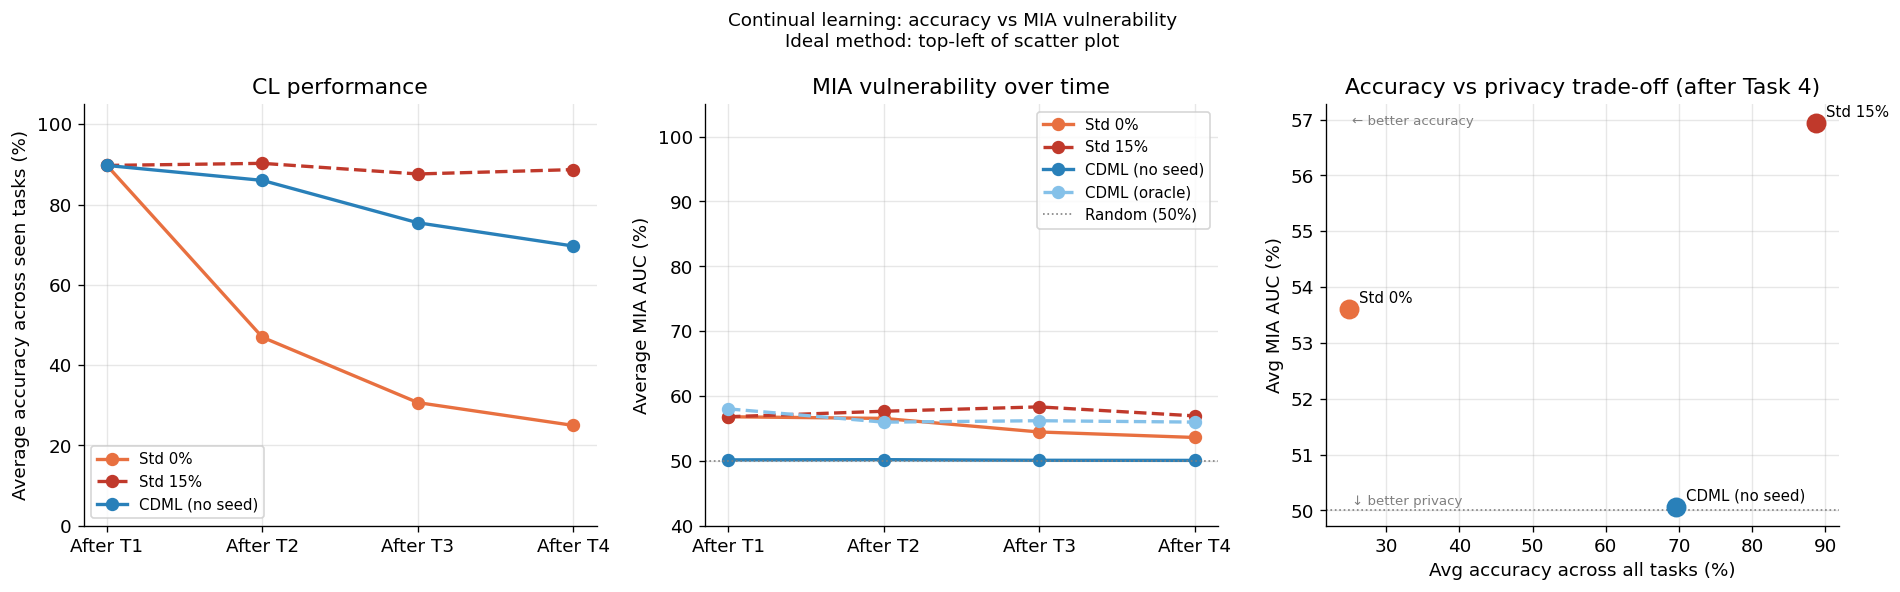

In [30]:
task_colors = ['#4C9BE8', '#6DB56D', '#E8864C', '#B06DB5']

all_configs = [
    ('Std 0%',          acc_std,   auc_std,          '#E87040', '-'),
    ('Std 15%',         acc_r15,   auc_r15,          '#C0392B', '--'),
    ('CDML (no seed)',  acc_cdml,  auc_cdml_noseed,  '#2980B9', '-'),
    ('CDML (oracle)',   acc_cdml,  auc_cdml_oracle,  '#85C1E9', '--'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Left: average accuracy per step ──────────────────────────────────────────
ax = axes[0]
for label, acc_mat, _, color, ls in all_configs:
    if 'oracle' in label: continue   # same accuracy as CDML no-seed
    avg = [np.nanmean(acc_mat[step, :step+1])*100 for step in range(n_tasks)]
    ax.plot(range(1, n_tasks+1), avg, 'o-', color=color, linestyle=ls,
            linewidth=2, markersize=7, label=label)
ax.set_xticks(range(1, n_tasks+1))
ax.set_xticklabels([f'After T{i}' for i in range(1, n_tasks+1)])
ax.set_ylabel('Average accuracy across seen tasks (%)')
ax.set_ylim(0, 105)
ax.legend(fontsize=9)
ax.set_title('CL performance')

# ── Middle: average MIA AUC per step ─────────────────────────────────────────
ax2 = axes[1]
for label, _, auc_mat, color, ls in all_configs:
    avg = [np.nanmean(auc_mat[step, :step+1]) for step in range(n_tasks)]
    ax2.plot(range(1, n_tasks+1), avg, 'o-', color=color, linestyle=ls,
             linewidth=2, markersize=7, label=label)
ax2.axhline(50, color='gray', linestyle=':', lw=1, label='Random (50%)')
ax2.set_xticks(range(1, n_tasks+1))
ax2.set_xticklabels([f'After T{i}' for i in range(1, n_tasks+1)])
ax2.set_ylabel('Average MIA AUC (%)')
ax2.set_ylim(40, 105)
ax2.legend(fontsize=9)
ax2.set_title('MIA vulnerability over time')

# ── Right: scatter — accuracy vs privacy leakage (final step only) ────────────
ax3 = axes[2]
for label, acc_mat, auc_mat, color, ls in all_configs:
    if 'oracle' in label: continue
    final_acc  = np.nanmean(acc_mat[-1, :]) * 100
    final_auc  = np.nanmean(auc_mat[-1, :])
    ax3.scatter(final_acc, final_auc, color=color, s=120, zorder=5)
    ax3.annotate(label, (final_acc, final_auc),
                 textcoords='offset points', xytext=(6, 4), fontsize=9)
ax3.axhline(50, color='gray', linestyle=':', lw=1)
ax3.set_xlabel('Avg accuracy across all tasks (%)')
ax3.set_ylabel('Avg MIA AUC (%)')
ax3.set_title('Accuracy vs privacy trade-off (after Task 4)')
ax3.text(0.05, 0.95, '← better accuracy', transform=ax3.transAxes, fontsize=8, color='gray')
ax3.text(0.05, 0.05, '↓ better privacy', transform=ax3.transAxes, fontsize=8, color='gray')

fig.suptitle('Continual learning: accuracy vs MIA vulnerability\n'
             'Ideal method: top-left of scatter plot', fontsize=11)
plt.tight_layout()
plt.savefig('fig_mia_comparison.png', bbox_inches='tight')
plt.show()

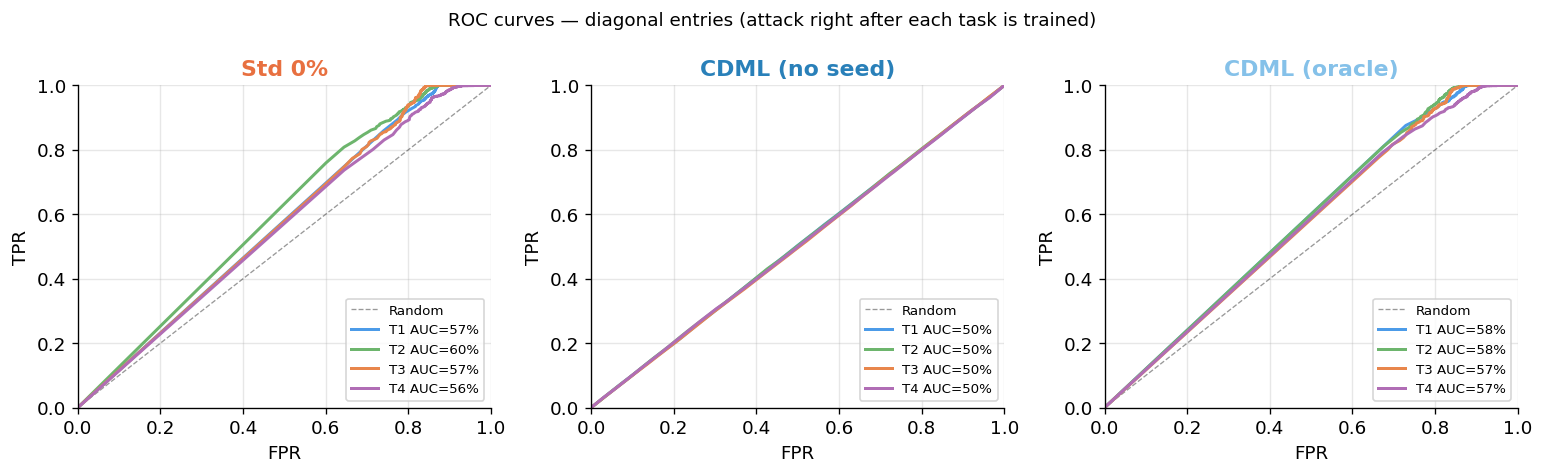

In [31]:
# ── ROC curves: Std 0% vs CDML no-seed vs CDML oracle — after Task 1 ──────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

roc_configs = [
    ('Std 0%',         roc_std,         '#E87040'),
    ('CDML (no seed)', roc_cdml_noseed, '#2980B9'),
    ('CDML (oracle)',  roc_cdml_oracle, '#85C1E9'),
]

for ax, (label, roc_dict, color) in zip(axes, roc_configs):
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.4, label='Random')
    for eval_idx, tc in enumerate(task_colors):
        # Use step_idx = eval_idx (diagonal: attack right after training on that task)
        key = (eval_idx, eval_idx)
        if key in roc_dict:
            fpr, tpr, ra, er = roc_dict[key]
            ax.plot(fpr, tpr, color=tc, lw=1.8,
                    label=f'T{eval_idx+1} AUC={ra*100:.0f}%')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(label, color=color, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle('ROC curves — diagonal entries (attack right after each task is trained)',
             fontsize=11)
plt.tight_layout()
plt.savefig('fig_roc_diagonal.png', bbox_inches='tight')
plt.show()

## 10. Summary table

In [33]:
print('── Final summary (after Task 4): average accuracy and MIA AUC ──')
print(f'  {"Method":<22} {"Avg Acc":>10} {"Avg AUC":>10} {"Task1 AUC":>12} {"Privacy"}')
print('  ' + '─' * 65)

summary_configs = [
    ('Std 0%',          acc_std,  auc_std),
    ('Std 15% replay',  acc_r15,  auc_r15),
    ('CDML (no seed)',  acc_cdml, auc_cdml_noseed),
    ('CDML (oracle)',   acc_cdml, auc_cdml_oracle),
]

for label, acc_mat, auc_mat in summary_configs:
    final_acc  = np.nanmean(acc_mat[-1, :])  * 100
    final_auc  = np.nanmean(auc_mat[-1, :])
    t1_auc     = auc_mat[-1, 0]   # AUC for Task 1 at final step
    privacy    = 'PROTECTED' if final_auc < 60 else 'VULNERABLE'
    t1_str     = f'{t1_auc:.1f}%' if not np.isnan(t1_auc) else '—'
    print(f'  {label:<22} {final_acc:>9.1f}% {final_auc:>9.1f}% {t1_str:>12}  {privacy}')

print()
print('Key results to highlight in thesis:')
print('1. Replay improves CL accuracy but INCREASES MIA vulnerability for old tasks')
print('2. CDML (no seed) achieves protection comparable to random guessing')
print('3. CDML oracle attack shows the protection is entirely due to seed secrecy')
print('4. CDML achieves better old-task accuracy than Std 0% with better privacy than Std 30%')

── Final summary (after Task 4): average accuracy and MIA AUC ──
  Method                    Avg Acc    Avg AUC    Task1 AUC Privacy
  ─────────────────────────────────────────────────────────────────
  Std 0%                      25.0%      53.6%        51.7%  PROTECTED
  Std 15% replay              88.7%      56.9%        55.4%  PROTECTED
  CDML (no seed)              69.7%      50.1%        50.1%  PROTECTED
  CDML (oracle)               69.7%      56.0%        52.4%  PROTECTED

Key results to highlight in thesis:
1. Replay improves CL accuracy but INCREASES MIA vulnerability for old tasks
2. CDML (no seed) achieves protection comparable to random guessing
3. CDML oracle attack shows the protection is entirely due to seed secrecy
4. CDML achieves better old-task accuracy than Std 0% with better privacy than Std 30%


In [35]:
import pickle
with open('mia_results_final.pkl', 'wb') as f:
    pickle.dump({
        'auc': {'std': auc_std, 'r15': auc_r15,
                'cdml_noseed': auc_cdml_noseed, 'cdml_oracle': auc_cdml_oracle},
        'eer': {'std': eer_std, 'r15': eer_r15,
                'cdml_noseed': eer_cdml_noseed, 'cdml_oracle': eer_cdml_oracle},
        'acc': {'std': acc_std, 'r15': acc_r15, 'cdml': acc_cdml},
    }, f)
print('Saved: mia_results_final.pkl')

Saved: mia_results_final.pkl
